#### Hough Transforms

- technique to detect shapes in images

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10.0, 10.0)
plt.rcParams['image.cmap'] = 'gray'

%matplotlib inline

Hough Lines

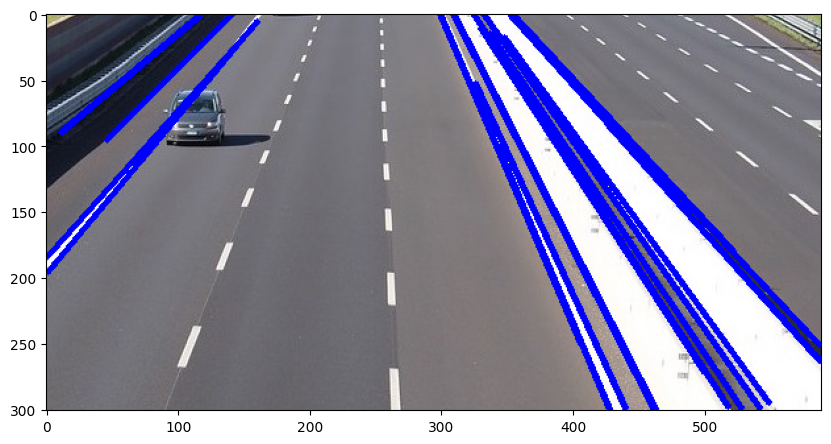

In [11]:
img = cv2.imread('data/images/lanes.jpg', cv2.IMREAD_COLOR)
# Convert the image to gray scale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Find the edges in the image using canny edge detector
edges = cv2.Canny(gray, 50, 200)
# Detect points that form a line
lines = cv2.HoughLinesP(edges, 1, np.pi/180, 100, minLineLength=10, maxLineGap=250)
# Draw lines on the image
for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(img, (x1, y1), (x2, y2), (255, 0, 0), 3)

plt.imshow(img[:,:,::-1])

Hough Circles

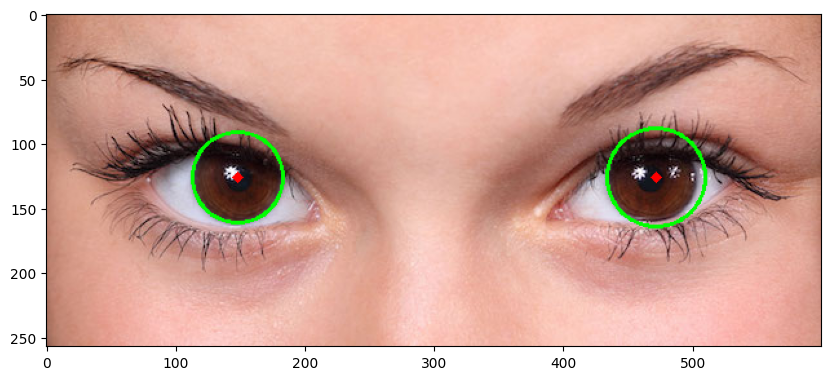

In [ ]:
img = cv2.imread('data/images/circles.jpg', cv2.IMREAD_COLOR)
# Convert the image to gray scale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Blur the image to reduce noise
gray_blurred = cv2.medianBlur(gray, 5)
# Apply hough transforms on the image
circles = cv2.HoughCircles(gray_blurred, cv2.HOUGH_GRADIENT, 1, 50, param1=10, param2=25, minRadius=30, maxRadius=40)
# circles = cv2.HoughCircles(img_blur, cv2.HOUGH_GRADIENT, 1, 50, param1=450, param2=10, minRadius=30, maxRadius=40)  # Original parameters
# Draw detected circles on the image
if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        # Draw outer circle
        cv2.circle(img, (i[0], i[1]), i[2], (0, 255, 0), 2)
        # Draw inner circle
        cv2.circle(img, (i[0], i[1]), 2, (0, 0, 255), 3)
plt.imshow(img[:,:,::-1])

- HDR Imaging

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
times = np.array([ 1/30.0, 0.25, 2.5, 15.0], dtype=np.float32)
filenames = ['data/images/img_0.033.jpg', 'data/images/img_0.25.jpg', 'data/images/img_2.5.jpg', 'data/images/img_15.jpg']
# Read the images
images = [cv2.imread(file) for file in filenames]

Text(0, 0.5, 'Calibrated Intensity')

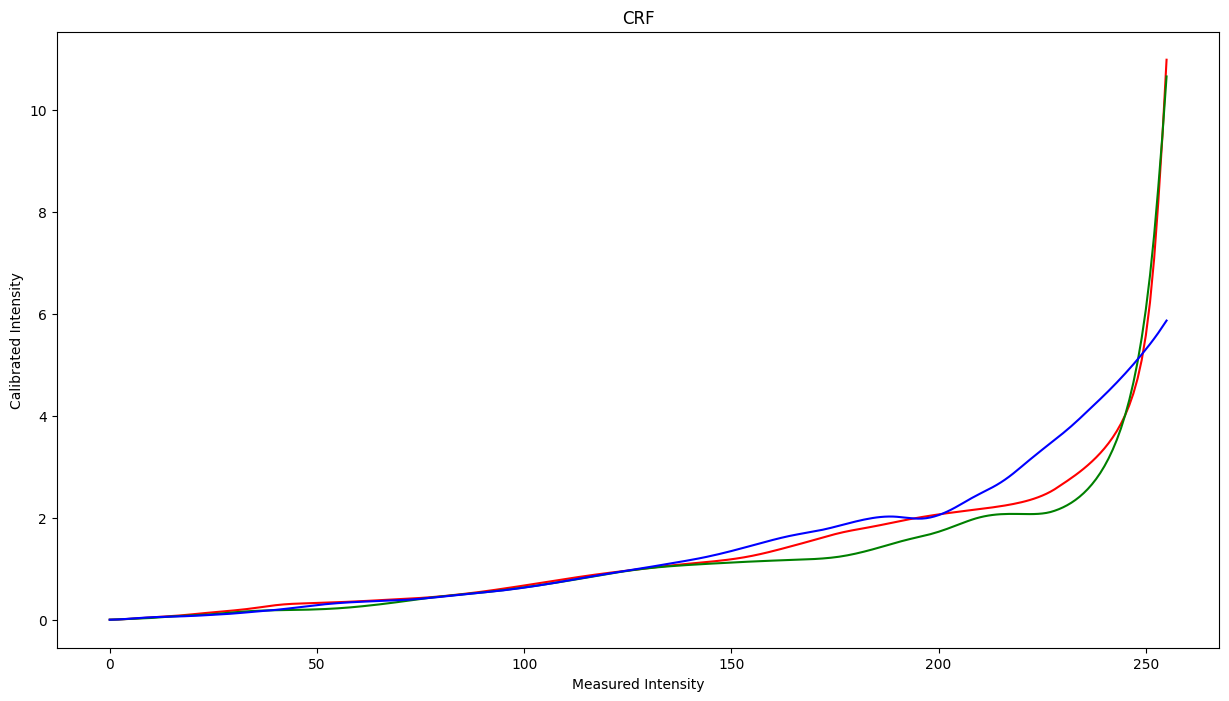

In [28]:
# Align the images
alignMTB = cv2.createAlignMTB()
alignMTB.process(images, images)

# Recover the camera response function (CRF)
calibrateDebevec = cv2.createCalibrateDebevec()
responseDebevec = calibrateDebevec.process(images, times)

# plot CRF
x = np.arange(256, dtype=np.uint8)
y = np.squeeze(responseDebevec)

plt.figure(figsize=(15,8))
plt.plot(x, y[:,0],'r'  , x, y[:,1],'g', x, y[:,2],'b');
plt.title("CRF")
plt.xlabel("Measured Intensity")
plt.ylabel("Calibrated Intensity")

In [30]:
responseDebevec.shape

(256, 1, 3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.870294e-11..3.0].


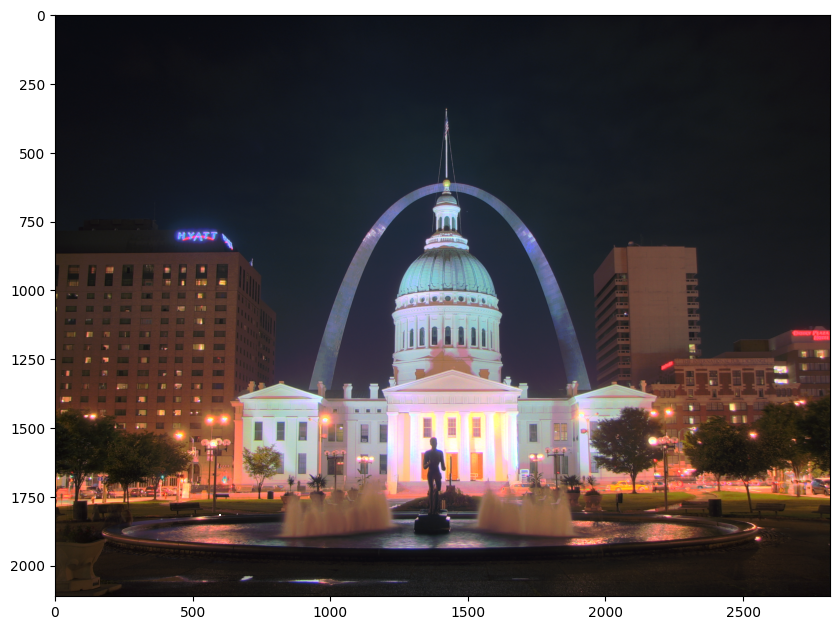

In [31]:
# Merge images into an HDR linear image
mergeDebevec = cv2.createMergeDebevec()
hdrDebevec = mergeDebevec.process(images, times, responseDebevec)

# Save the HDR image
cv2.imwrite('data/images/hdrDebevec.hdr', hdrDebevec)

# Tonemap using Drago's method to obtain 24-bit color image
# Purely for esthetic reasons, we can also use different tonemap functions
tonemapDrago = cv2.createTonemapDrago(1.0, 0.7)
ldrDrago = tonemapDrago.process(hdrDebevec)
ldrDrago = 3 * ldrDrago
plt.imshow(ldrDrago[:,:,::-1])


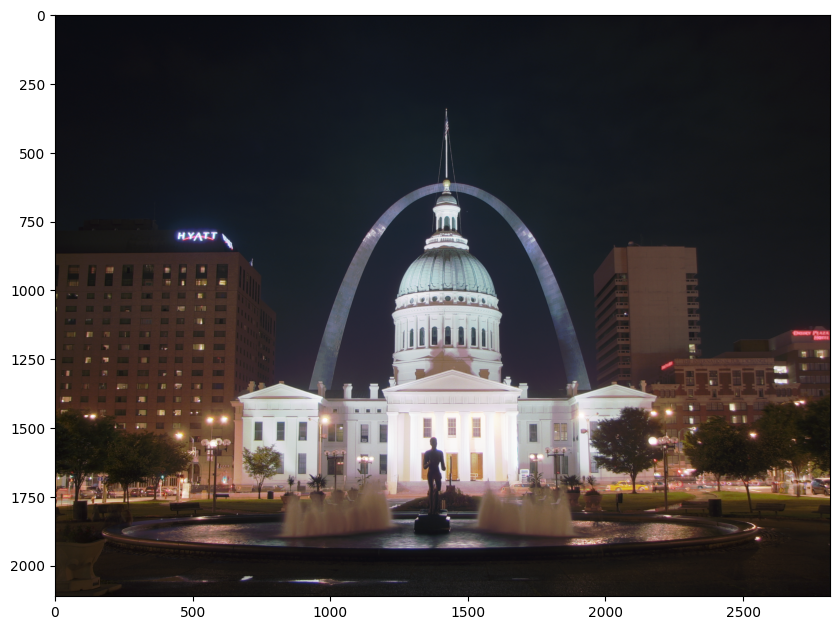

In [32]:
# Tonemap using Reinhard's method to obtain 24-bit color image
tonemapReinhard = cv2.createTonemapReinhard(1.5, 0,0,0)
ldrReinhard = tonemapReinhard.process(hdrDebevec)
plt.imshow(ldrReinhard[:,:,::-1])

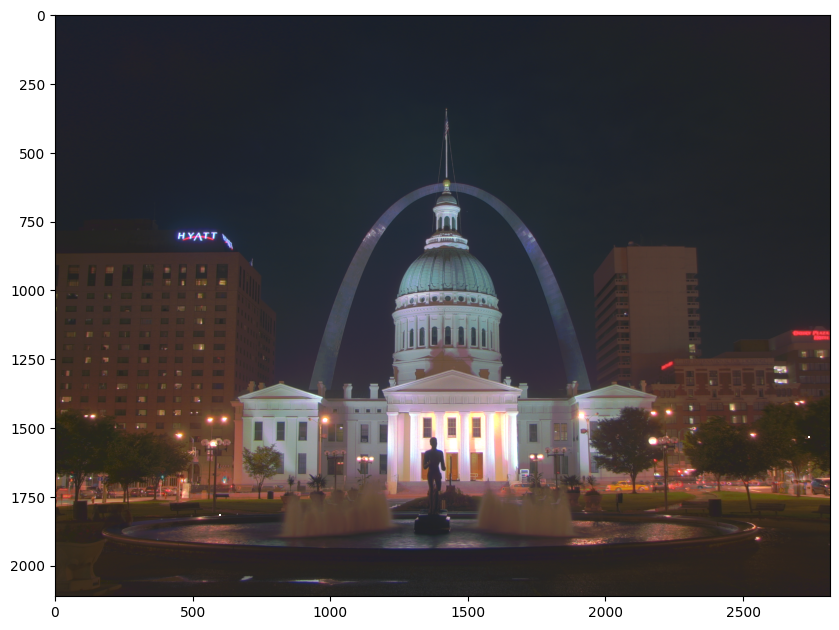

In [33]:
# Tonemap using Mantiuk's method to obtain 24-bit color image
tonemapMantiuk = cv2.createTonemapMantiuk(2.2,0.85, 1.2)
ldrMantiuk = tonemapMantiuk.process(hdrDebevec)
ldrMantiuk = np.clip(3 * ldrMantiuk,0,1)
plt.imshow(ldrMantiuk[:,:,::-1])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.870294e-11..3.0].


(np.float64(-0.5), np.float64(2815.5), np.float64(2111.5), np.float64(-0.5))

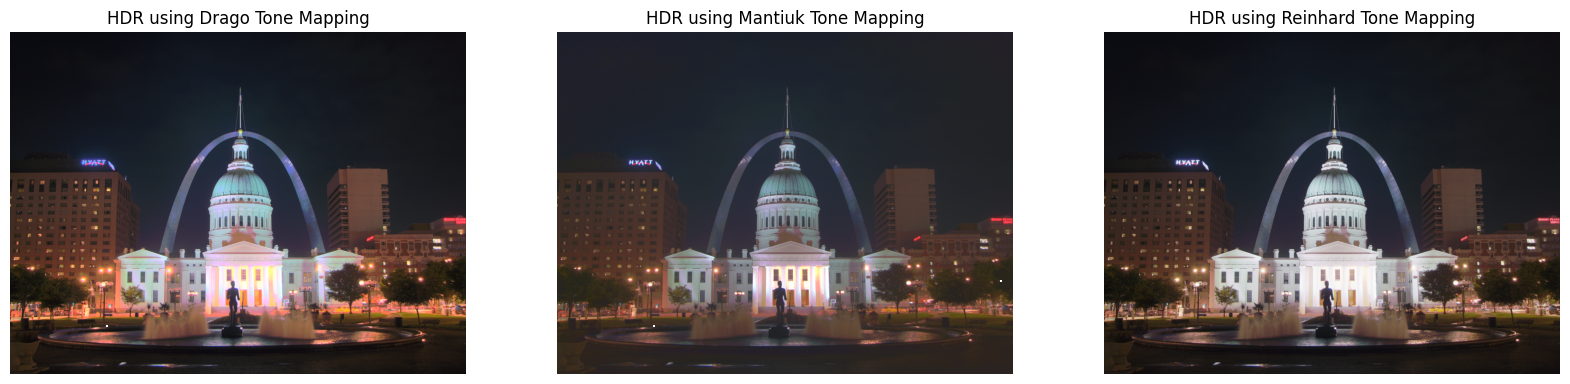

In [34]:
plt.figure(figsize=[20,10])
plt.subplot(131);plt.imshow(ldrDrago[:,:,::-1]);plt.title("HDR using Drago Tone Mapping");plt.axis('off')
plt.subplot(132);plt.imshow(ldrMantiuk[:,:,::-1]);plt.title("HDR using Mantiuk Tone Mapping");plt.axis('off')
plt.subplot(133);plt.imshow(ldrReinhard[:,:,::-1]);plt.title("HDR using Reinhard Tone Mapping");plt.axis('off')

#### Seamless cloning

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
src = cv2.imread('data/images/airplane.jpg')
dst = cv2.imread('data/images/sky.jpg')

In [4]:
srcMask = np.zeros(src.shape, src.dtype)
poly = np.array([ [4,80], [30,54], [151,63], [254,37], [298,90], [272,134], [43,122] ], np.int32)
srcMask = cv2.fillPoly(srcMask, [poly], (255, 255, 255))

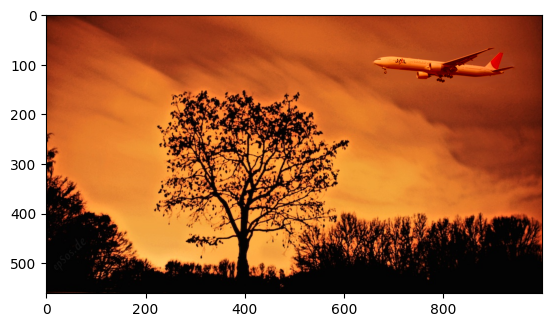

In [7]:
center = (800, 100)
output = cv2.seamlessClone(src, dst, srcMask, center, cv2.NORMAL_CLONE)
plt.imshow(output[:,:,::-1])

(np.float64(-0.5), np.float64(304.5), np.float64(123.5), np.float64(-0.5))

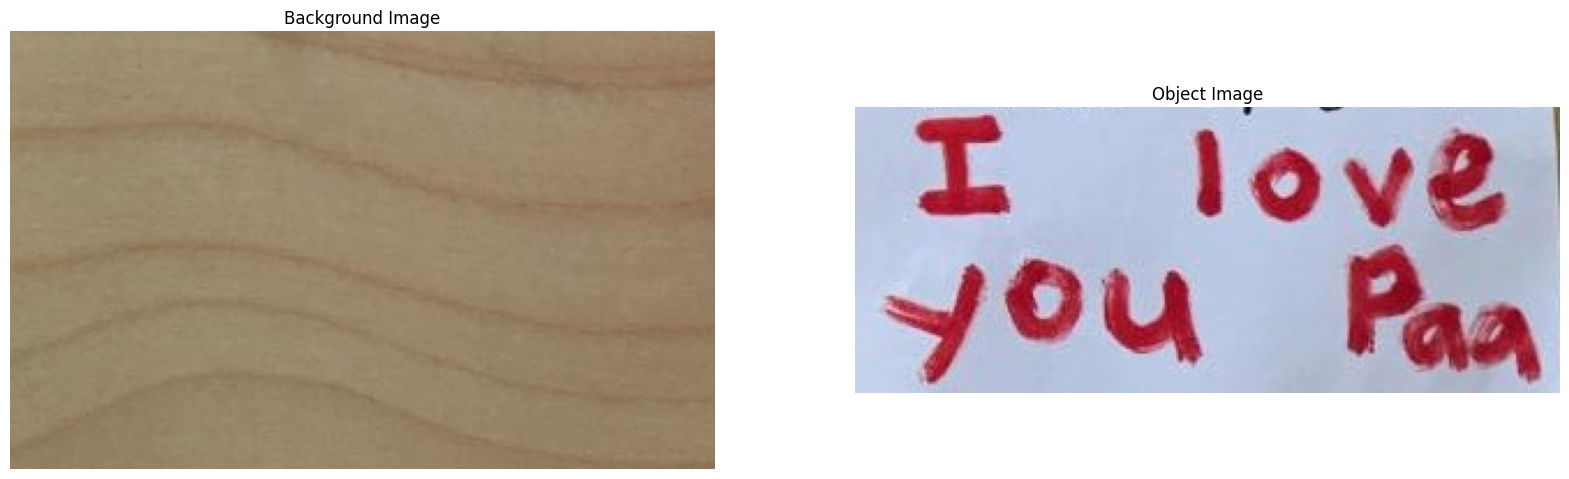

In [12]:
im = cv2.imread("data/images/wood-texture.jpg")
obj= cv2.imread("data/images/iloveyouticket.jpg")

plt.figure(figsize=[20,10])
plt.subplot(121);plt.imshow(im[:,:,::-1]);plt.title("Background Image");plt.axis('off');
plt.subplot(122);plt.imshow(obj[:,:,::-1]);plt.title("Object Image");plt.axis('off')

In [15]:
mask = 255 * np.ones(obj.shape, obj.dtype)

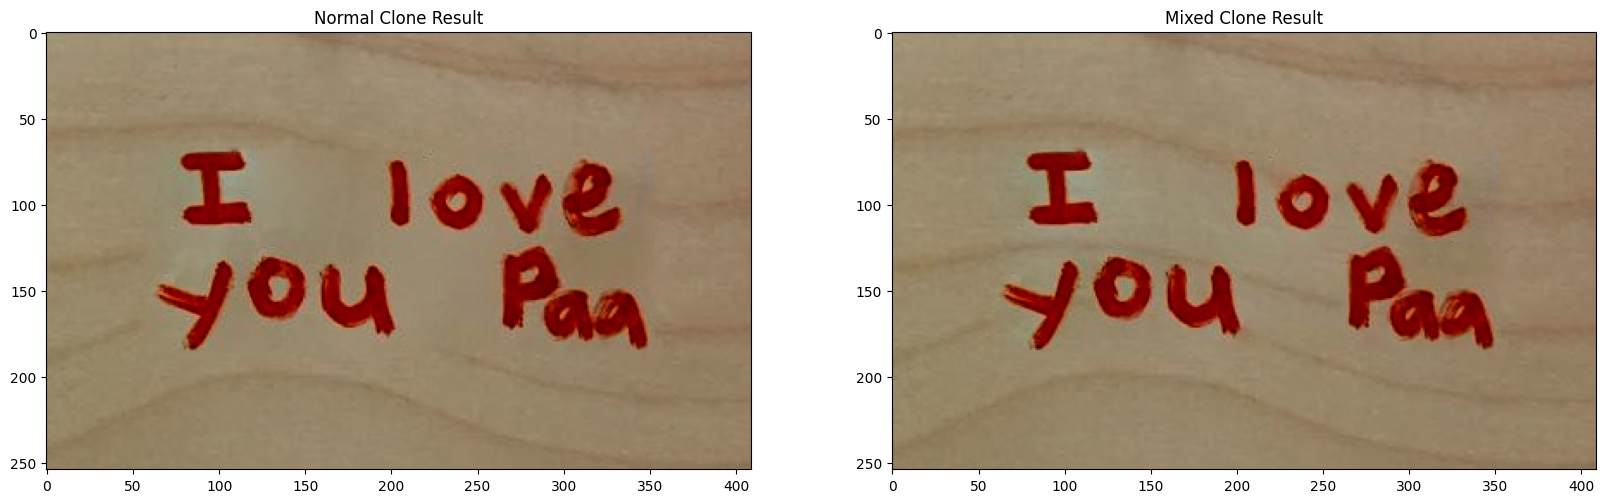

In [16]:
width, height, channels = im.shape
center = (height//2, width//2)

normalClone = cv2.seamlessClone(obj, im, mask, center, cv2.NORMAL_CLONE)
mixedClone = cv2.seamlessClone(obj, im, mask, center, cv2.MIXED_CLONE)

plt.figure(figsize=[20,10])
plt.subplot(1,2,1)
plt.title("Normal Clone Result")
plt.imshow(normalClone[:,:,::-1])
plt.subplot(1,2,2)
plt.title("Mixed Clone Result")
plt.imshow(mixedClone[:,:,::-1])
plt.show()

#### Face Blending

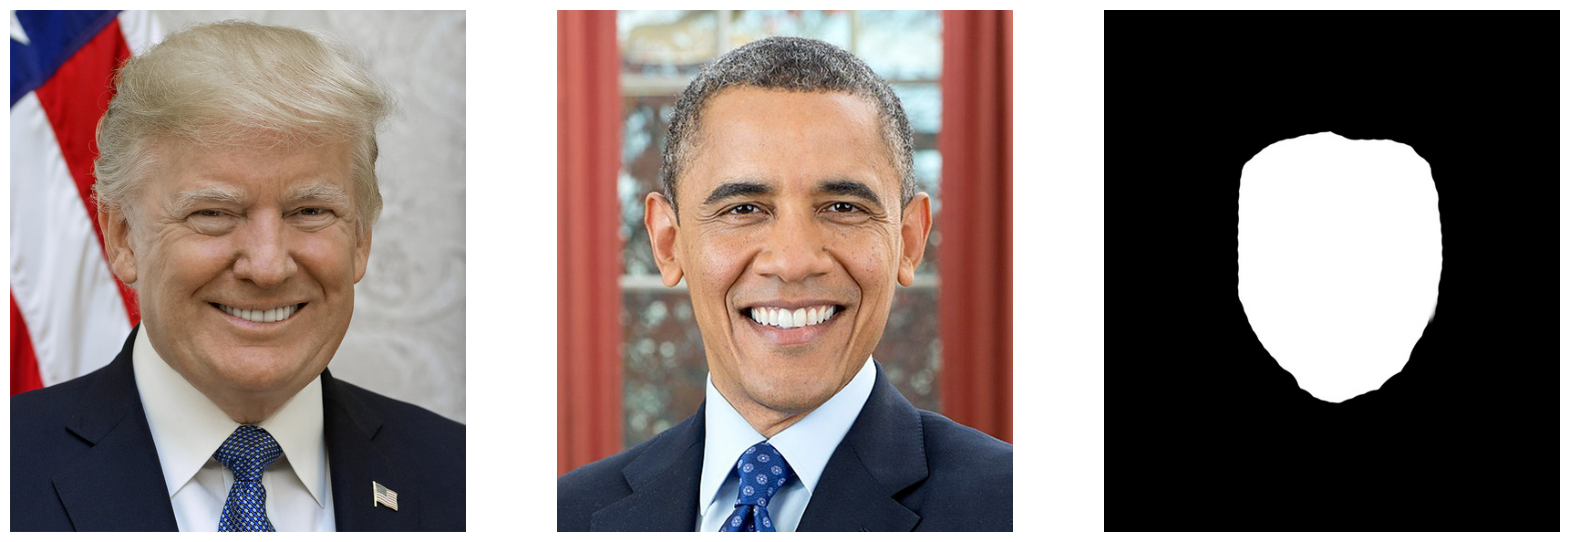

In [17]:
dst = cv2.imread('data/images/trump.jpg')
dst = cv2.cvtColor(dst, cv2.COLOR_BGR2RGB)

src = cv2.imread('data/images/obama.jpg')
src = cv2.cvtColor(src, cv2.COLOR_BGR2RGB)

srcMask = cv2.imread('data/images/obama-mask.jpg', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(20,10)); 

plt.subplot(131); plt.imshow(dst); plt.axis('off'); 
plt.subplot(132); plt.imshow(src); plt.axis('off'); 
plt.subplot(133); plt.imshow(srcMask, cmap='gray'); plt.axis('off');

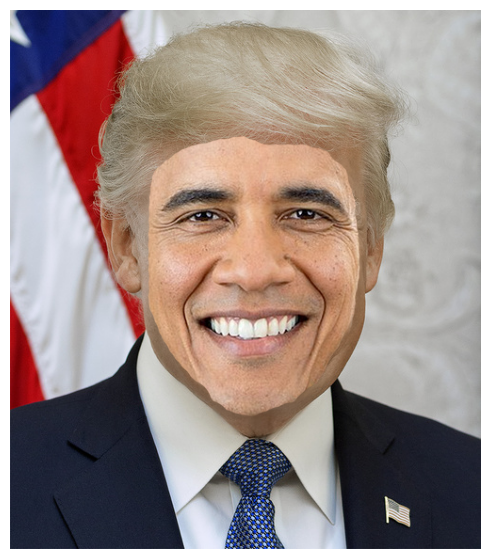

In [18]:
alpha = cv2.cvtColor(srcMask.copy(), cv2.COLOR_GRAY2RGB)
alpha = alpha.astype(np.float32) / 255.0
outputBlend = src*alpha+dst*(1-alpha)
outputBlend = outputBlend.astype(np.uint8)
plt.figure(figsize=(7,7));plt.imshow(outputBlend);plt.axis('off');

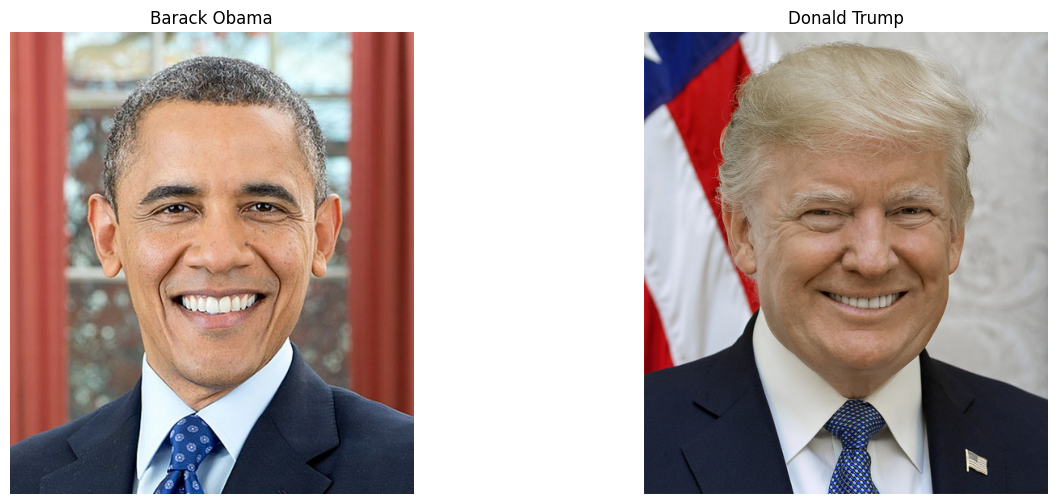

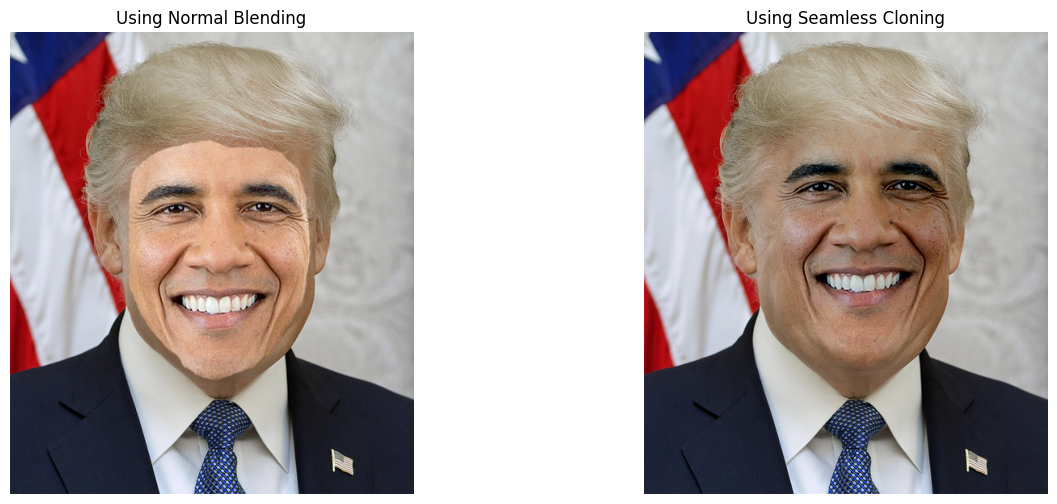

In [22]:
# find the center of the srcmask
ret, srcMaskBin = cv2.threshold(srcMask, 128, 255, cv2.THRESH_BINARY)
m = cv2.moments(srcMaskBin)
center = (int(m['m01']/m['m00']), int(m['m10']/m['m00']))
outputClone = cv2.seamlessClone(src, dst, srcMask, center, cv2.NORMAL_CLONE)

plt.figure(figsize=(15,6)); 
plt.subplot(121); plt.imshow(src); plt.title("Barack Obama");plt.axis('off'); 
plt.subplot(122); plt.imshow(dst);  plt.title("Donald Trump");plt.axis('off'); 
plt.figure(figsize=(15,6)); 
plt.subplot(121); plt.imshow(outputBlend); plt.title("Using Normal Blending");plt.axis('off'); 
plt.subplot(122); plt.imshow(outputClone);  plt.title("Using Seamless Cloning");plt.axis('off');

#### Image Inpainting

In [2]:
class Sketcher:
    def __init__(self, windowname, dests, color_func):
        self.prev_pt = None
        self.windowname = windowname
        self.dests = dests
        self.color_func = color_func
        self.dirty = False
        self.show()
        cv2.setMouseCallback(self.windowname, self.on_mouse)
    
    def show(self):
        cv2.imshow(self.windowname, self.dests[0])
        cv2.imshow(self.windowname+": Mask", self.dests[1])

    def on_mouse(self, event, x, y, flags, param):
        pt = (x,y)
        if event == cv2.EVENT_LBUTTONDOWN:
            self.prev_pt = pt
        elif event == cv2.EVENT_LBUTTONUP:
            self.prev_pt = None
        
        if self.prev_pt and flags & cv2.EVENT_FLAG_LBUTTON:
            for dst, color in zip(self.dests, self.color_func()):
                cv2.line(dst, self.prev_pt, pt, color, 5)
            self.dirty = True
            self.prev_pt = pt
            self.show()

In [3]:
cv2.destroyAllWindows()

In [4]:
img = cv2.imread('data/images/Lincoln.jpg', cv2.IMREAD_COLOR)

imgMask = img.copy()
inpaintMask = np.zeros(img.shape[:2], dtype=np.uint8)
sketch = Sketcher('image', [imgMask, inpaintMask], lambda: ((0, 255, 0), 255))

In [ ]:
while True:
    ch = cv2.waitKey()
    if ch == 27:
        break
    if ch == ord('t'):
        res = cv2.inpaint(src=imgMask, inpaintMask = inpaintMask, inpaintRadius = 3, flags=cv2.INPAINT_TELEA)
        cv2.imshow('Inpaint Output using Telea', res) # (Fast Marching Method - FMM)
    if ch == ord('n'):
        res = cv2.inpaint(src=imgMask, inpaintMask=inpaintMask, inpaintRadius=3, flags=cv2.INPAINT_NS)
        cv2.imshow('Inpaint Output using NS Technique', res) # (Navier-Stokes based method)
    if ch == ord('r'):
        imgMask[:] = img
        inpaintMask[:] = 0
        sketch.show()


: 